<a href="https://colab.research.google.com/github/FABYG6/DL_Redes_Neuronales_Basicas/blob/main/Redes_Neuronales_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ========================================================
# Laboratorio A: datos, preprocesamiento y modelo baseline
# ========================================================
# Paso 1. Importar herramientas y fijar semillas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
# Paso 2. Cargar MNIST

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train original:", x_train_full.shape, y_train_full.shape)
print("Test:", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train original: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [ ]:
# Paso 3. Crear Train y Dev de forma estratificada

x_train, x_dev, y_train, y_dev = train_test_split(
    x_train_full, y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", x_train.shape, y_train.shape)
print("Dev:", x_dev.shape, y_dev.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (48000, 28, 28) (48000,)
Dev: (12000, 28, 28) (12000,)
Test: (10000, 28, 28) (10000,)


In [ ]:
# Paso 4. Normalizar los píxeles

x_train = x_train.astype("float32") / 255.0
x_dev   = x_dev.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Rango train:", x_train.min(), x_train.max())

Rango train: 0.0 1.0


In [ ]:
# Paso 5. Verificar la distribución de clases

def distribucion_clases(y, nombre):
    conteos = np.bincount(y, minlength=10)
    porcentajes = conteos / len(y) * 100
    tabla = pd.DataFrame({
        "digito": np.arange(10),
        "cantidad": conteos,
        "porcentaje": np.round(porcentajes, 2)
    })
    print("\n", nombre)
    display(tabla)
    return tabla

dist_train = distribucion_clases(y_train, "TRAIN")
dist_dev   = distribucion_clases(y_dev, "DEV")
dist_test  = distribucion_clases(y_test, "TEST")


 TRAIN


,digito,cantidad,porcentaje
0,0,4738,9.87
1,1,5394,11.24
2,2,4766,9.93
3,3,4905,10.22
4,4,4674,9.74
5,5,4337,9.04
6,6,4734,9.86
7,7,5012,10.44
8,8,4681,9.75
9,9,4759,9.91



 DEV


,digito,cantidad,porcentaje
0,0,1185,9.88
1,1,1348,11.23
2,2,1192,9.93
3,3,1226,10.22
4,4,1168,9.73
5,5,1084,9.03
6,6,1184,9.87
7,7,1253,10.44
8,8,1170,9.75
9,9,1190,9.92



 TEST


,digito,cantidad,porcentaje
0,0,980,9.80
1,1,1135,11.35
2,2,1032,10.32
3,3,1010,10.10
4,4,982,9.82
5,5,892,8.92
6,6,958,9.58
7,7,1028,10.28
8,8,974,9.74
9,9,1009,10.09


In [ ]:
# Paso 6. Crear el modelo baseline

def crear_modelo_baseline(units=128, optimizer=None):
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    if optimizer is None:
        optimizer = keras.optimizers.Adam(learning_rate=0.001)

    modelo.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

modelo_base = crear_modelo_baseline()
modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Paso 7. Entrenar usando Dev explícito

hist_base = modelo_base.fit(
    x_train, y_train,
    validation_data=(x_dev, y_dev),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9077 - loss: 0.3330 - val_accuracy: 0.9447 - val_loss: 0.1964
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9553 - loss: 0.1546 - val_accuracy: 0.9588 - val_loss: 0.1478
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9686 - loss: 0.1084 - val_accuracy: 0.9633 - val_loss: 0.1274
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9767 - loss: 0.0817 - val_accuracy: 0.9656 - val_loss: 0.1160
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9819 - loss: 0.0637 - val_accuracy: 0.9672 - val_loss: 0.1097


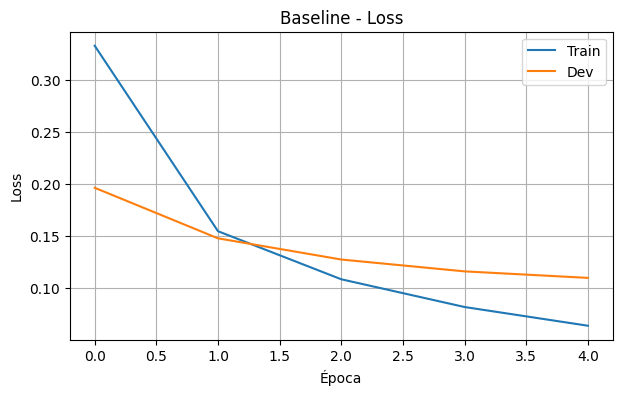

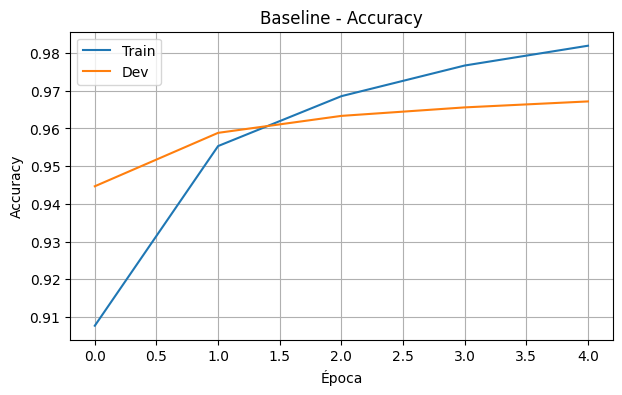

In [ ]:
# Paso 8. Graficar Loss y Accuracy

plt.figure(figsize=(7, 4))
plt.plot(hist_base.history["loss"], label="Train")
plt.plot(hist_base.history["val_loss"], label="Dev")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Baseline - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist_base.history["accuracy"], label="Train")
plt.plot(hist_base.history["val_accuracy"], label="Dev")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Baseline - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =============================================
# Laboratorio B: optimización e hiperparámetros
# =============================================
# Paso 9. Función para crear el mismo modelo

def crear_modelo_experimento(optimizador, units=128):
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(units, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    modelo.compile(
        optimizer=optimizador,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

In [ ]:
# Paso 10. Comparar SGD, RMSprop y Adam

fabricas_optimizadores = {
    "SGD_momentum": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.9
    ),
    "RMSprop": lambda: keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    "Adam": lambda: keras.optimizers.Adam(
        learning_rate=0.001
    )
}

resultados_opt = []
historias_opt = {}

for nombre, fabrica in fabricas_optimizadores.items():
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    modelo = crear_modelo_experimento(fabrica())

    historia = modelo.fit(
        x_train, y_train,
        validation_data=(x_dev, y_dev),
        epochs=5,
        batch_size=64,
        verbose=0
    )

    historias_opt[nombre] = historia
    resultados_opt.append({
        "optimizador": nombre,
        "train_accuracy": historia.history["accuracy"][-1],
        "dev_accuracy": historia.history["val_accuracy"][-1],
        "dev_loss": historia.history["val_loss"][-1]
    })

tabla_opt = pd.DataFrame(resultados_opt)
display(tabla_opt)

,optimizador,train_accuracy,dev_accuracy,dev_loss
0,SGD_momentum,0.966396,0.957417,0.145949
1,RMSprop,0.980792,0.971667,0.101910
2,Adam,0.983167,0.965333,0.119568


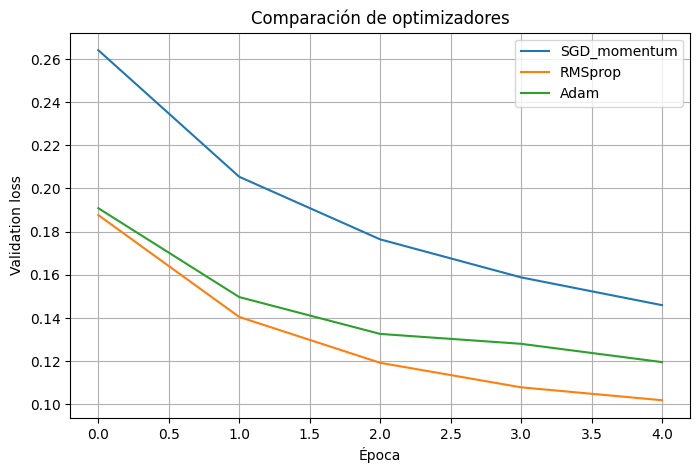

In [ ]:
# Paso 11. Comparar visualmente Validation Loss

plt.figure(figsize=(8, 5))
for nombre, historia in historias_opt.items():
    plt.plot(historia.history["val_loss"], label=nombre)

plt.xlabel("Época")
plt.ylabel("Validation loss")
plt.title("Comparación de optimizadores")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Paso 12. Explorar el Learning Rate de Adam

learning_rates = [0.0001, 0.001, 0.01]
resultados_lr = []

for lr in learning_rates:
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    modelo = crear_modelo_experimento(
        keras.optimizers.Adam(learning_rate=lr)
    )

    historia = modelo.fit(
        x_train, y_train,
        validation_data=(x_dev, y_dev),
        epochs=3,
        batch_size=64,
        verbose=0
    )

    resultados_lr.append({
        "learning_rate": lr,
        "train_accuracy": historia.history["accuracy"][-1],
        "dev_accuracy": historia.history["val_accuracy"][-1],
        "dev_loss": historia.history["val_loss"][-1]
    })

display(pd.DataFrame(resultados_lr))

,learning_rate,train_accuracy,dev_accuracy,dev_loss
0,0.0001,0.918646,0.923500,0.283028
1,0.0010,0.969979,0.961833,0.130784
2,0.0100,0.965729,0.951167,0.213207


In [ ]:
# ===========================================
# Laboratorio C: regularización y overfitting
# ===========================================
# Paso 13. Crear una muestra para el experimento

x_train_reg, _, y_train_reg, _ = train_test_split(
    x_train, y_train,
    train_size=12000,
    random_state=SEED,
    stratify=y_train
)

print("Muestra:", x_train_reg.shape, y_train_reg.shape)

Muestra: (12000, 28, 28) (12000,)


In [ ]:
# Paso 14. Modelo sin regularización

def crear_modelo_sin_regularizacion():
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

modelo_sin_reg = crear_modelo_sin_regularizacion()
hist_sin_reg = modelo_sin_reg.fit(
    x_train_reg, y_train_reg,
    validation_data=(x_dev, y_dev),
    epochs=15,
    batch_size=64,
    verbose=0
)

In [ ]:
# Paso 15. Modelo con L2, Dropout y Early Stopping

def crear_modelo_regularizado():
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(
            512, activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(0.30),
        layers.Dense(
            256, activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax")
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

parada_temprana = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

modelo_reg = crear_modelo_regularizado()
hist_reg = modelo_reg.fit(
    x_train_reg, y_train_reg,
    validation_data=(x_dev, y_dev),
    epochs=20,
    batch_size=64,
    callbacks=[parada_temprana],
    verbose=0
)

print("Épocas ejecutadas:", len(hist_reg.history["loss"]))

Épocas ejecutadas: 10


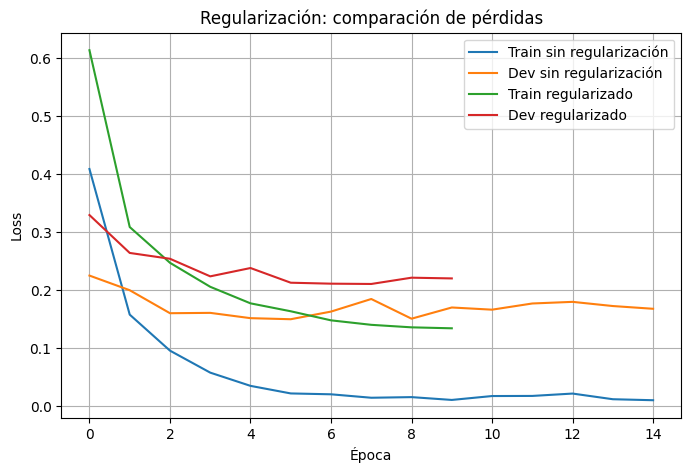

In [ ]:
# Paso 16. Comparar curvas

plt.figure(figsize=(8, 5))
plt.plot(hist_sin_reg.history["loss"], label="Train sin regularización")
plt.plot(hist_sin_reg.history["val_loss"], label="Dev sin regularización")
plt.plot(hist_reg.history["loss"], label="Train regularizado")
plt.plot(hist_reg.history["val_loss"], label="Dev regularizado")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Regularización: comparación de pérdidas")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Paso 17. Evaluar ambos modelos en Dev

dev_sin_reg = modelo_sin_reg.evaluate(x_dev, y_dev, verbose=0)
dev_reg = modelo_reg.evaluate(x_dev, y_dev, verbose=0)

print("Sin regularización - dev loss/accuracy:", dev_sin_reg)
print("Regularizado      - dev loss/accuracy:", dev_reg)

Sin regularización - dev loss/accuracy: [0.16826657950878143, 0.9651666879653931]
Regularizado      - dev loss/accuracy: [0.2110186368227005, 0.9639166593551636]


In [ ]:
# =====================================
# Laboratorio D: métricas de evaluación
# =====================================
# Paso 18. Generar predicciones

probabilidades_test = modelo_reg.predict(x_test, verbose=0)
y_pred = np.argmax(probabilidades_test, axis=1)

print("Primeras predicciones:", y_pred[:20])
print("Primeras clases reales:", y_test[:20])

Primeras predicciones: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
Primeras clases reales: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [ ]:
# Paso 19. Accuracy, Precision, Recall y F1

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)
recall_macro = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)
f1_macro = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

print("Accuracy:", round(accuracy, 4))
print("Precision macro:", round(precision_macro, 4))
print("Recall macro:", round(recall_macro, 4))
print("F1 macro:", round(f1_macro, 4))

Accuracy: 0.9661
Precision macro: 0.9658
Recall macro: 0.966
F1 macro: 0.9658


In [ ]:
# Paso 20. Crear una tabla de métricas

metricas = pd.DataFrame({
    "metrica": ["Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    "resultado": [accuracy, precision_macro, recall_macro, f1_macro]
})

display(metricas)

,metrica,resultado
0,Accuracy,0.966100
1,Precision macro,0.965792
2,Recall macro,0.965962
3,F1 macro,0.965752


In [ ]:
# Paso 21. Reporte por cada dígito
print(
    classification_report(
        y_test, y_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9650    0.9857    0.9753       980
           1     0.9791    0.9903    0.9847      1135
           2     0.9788    0.9380    0.9579      1032
           3     0.9609    0.9723    0.9665      1010
           4     0.9655    0.9695    0.9675       982
           5     0.9535    0.9664    0.9599       892
           6     0.9591    0.9781    0.9685       958
           7     0.9726    0.9660    0.9693      1028
           8     0.9462    0.9579    0.9520       974
           9     0.9772    0.9356    0.9559      1009

    accuracy                         0.9661     10000
   macro avg     0.9658    0.9660    0.9658     10000
weighted avg     0.9663    0.9661    0.9660     10000



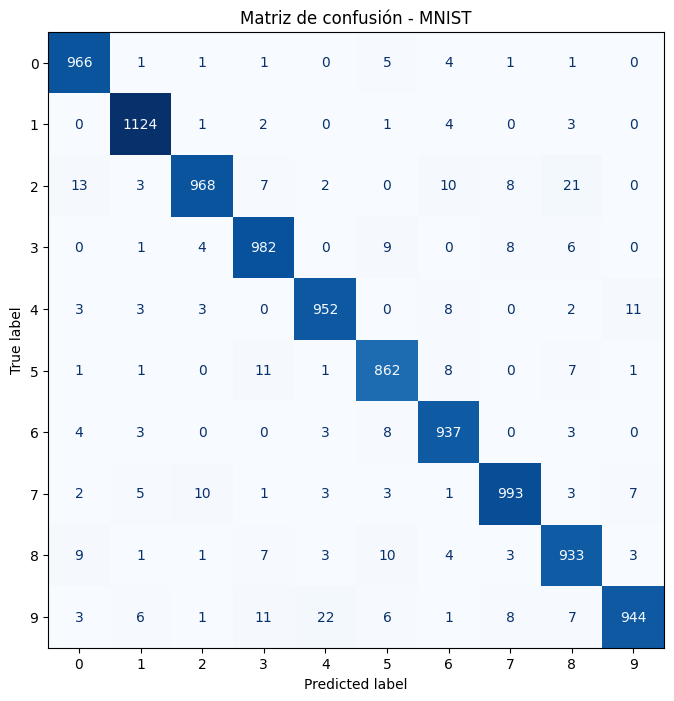

In [ ]:
# Paso 22. Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - MNIST")
plt.show()

In [ ]:
# Paso 23. Encontrar la confusión más frecuente

cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)

real_confundido, predicho_como = np.unravel_index(
    np.argmax(cm_errores),
    cm_errores.shape
)

cantidad = cm_errores[real_confundido, predicho_como]

print(
    f"La confusión más frecuente fue: "
    f"{real_confundido} clasificado como {predicho_como} "
    f"({cantidad} veces)"
)

La confusión más frecuente fue: 9 clasificado como 4 (22 veces)


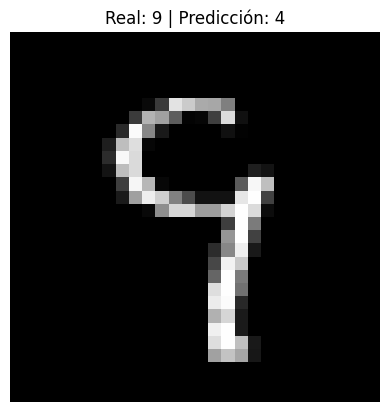

In [ ]:
# Paso 24. Visualizar un error real

indices = np.where(
    (y_test == real_confundido) &
    (y_pred == predicho_como)
)[0]

if len(indices) > 0:
    idx = indices[0]
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(
        f"Real: {y_test[idx]} | Predicción: {y_pred[idx]}"
    )
    plt.axis("off")
    plt.show()


In [ ]:
# ========================================
# Laboratorio E: bias, variance y tradeoff
# ========================================
# Paso 25. Modelo intencionalmente pequeño

modelo_pequeno = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_pequeno.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_pequeno = modelo_pequeno.fit(
    x_train, y_train,
    validation_data=(x_dev, y_dev),
    epochs=2,
    batch_size=64,
    verbose=0
)


In [ ]:
# Paso 26. Resumir la brecha Train-Dev
def resumen_historia(nombre, historia):
    train_acc = historia.history["accuracy"][-1]
    dev_acc = historia.history["val_accuracy"][-1]
    return {
        "modelo": nombre,
        "train_accuracy": train_acc,
        "dev_accuracy": dev_acc,
        "brecha_train_dev": train_acc - dev_acc
    }

tabla_diagnostico = pd.DataFrame([
    resumen_historia("Pequeño", hist_pequeno),
    resumen_historia("Sin regularización", hist_sin_reg),
    resumen_historia("Regularizado", hist_reg)
])

display(tabla_diagnostico)


,modelo,train_accuracy,dev_accuracy,brecha_train_dev
0,Pequeño,0.920187,0.921417,-0.001229
1,Sin regularización,0.996500,0.965167,0.031333
2,Regularizado,0.981833,0.964583,0.017250


In [ ]:
# ===================================
# 10. Laboratorio F opcional: PyTorch
# ===================================
# Paso 27. Modelo PyTorch con Dropout y L2

import torch
import torch.nn as nn
import torch.optim as optim

class RedMNISTRegularizada(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.30)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

modelo_torch = RedMNISTRegularizada()
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(
    modelo_torch.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(modelo_torch)


RedMNISTRegularizada(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
